# Applied Question 8: Nonlinear Modeling of the `Auto` Data

## Doug Perez

### School of Engineering & Technology, National University
### DDS 8555 -- Predictive Analytics
### Dr. Javier Leon
### August 12, 2026


**Text:** *An Introduction to Statistical Learning with Applications in Python*  
**Chapter 7, Applied Question 8 (p. 327)**

## Purpose
This analysis investigates whether nonlinear relationships are present in the `Auto` data.  Miles per gallon (`mpg`) is treated as the response.  The principal continuous predictors are examined with polynomial regression and cubic regression splines.  Model complexity is selected using shuffled 10-fold cross-validation, formal partial $F$-tests assess departures from linearity, and additive linear and spline models are compared using out-of-sample root mean squared error (RMSE).

## Analytical approach

For each continuous predictor, the analysis compares polynomial models of degrees 1 through 5 and cubic regression splines containing 3 through 7 knots.  The model with the smallest 10-fold cross-validated RMSE is retained.  A partial $F$-test then compares a linear model with a cubic polynomial model:

$$H_0: \beta_2 = \beta_3 = 0$$

Rejection of this null hypothesis indicates that the quadratic and cubic terms jointly explain variation beyond the linear term.  Cross-validation complements this inferential test by determining whether the additional flexibility improves prediction on observations excluded from model fitting.

In [1]:
# If needed, install ISLP before running the notebook:
%pip install ISLP

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display
from ISLP import load_data
from scipy.stats import f
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import (
    OneHotEncoder, PolynomialFeatures, SplineTransformer, StandardScaler
)

sns.set_theme(style='whitegrid', context='notebook')
RANDOM_STATE = 1



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
Defaulting to user installation because normal site-packages is not writeable


In [2]:
Auto = load_data('Auto').copy()

response = 'mpg'
continuous = ['horsepower', 'weight', 'displacement', 'acceleration', 'year']
categorical = ['cylinders', 'origin']

analysis_columns = [response] + continuous + categorical
Auto = Auto[analysis_columns].dropna().reset_index(drop=True)
y = Auto[response].to_numpy()

print(f'Observations: {len(Auto):,}')
print(f'Missing values after cleaning: {Auto.isna().sum().sum()}')
display(Auto.head())
display(Auto.describe().T.round(2))


Observations: 392
Missing values after cleaning: 0


,mpg,horsepower,weight,displacement,acceleration,year,cylinders,origin
0,18.0,130,3504,307.0,12.0,70,8,1
1,15.0,165,3693,350.0,11.5,70,8,1
2,18.0,150,3436,318.0,11.0,70,8,1
3,16.0,150,3433,304.0,12.0,70,8,1
4,17.0,140,3449,302.0,10.5,70,8,1


,count,mean,std,min,25%,50%,75%,max
mpg,392.0,23.45,7.81,9.0,17.00,22.75,29.00,46.6
horsepower,392.0,104.47,38.49,46.0,75.00,93.50,126.00,230.0
weight,392.0,2977.58,849.40,1613.0,2225.25,2803.50,3614.75,5140.0
displacement,392.0,194.41,104.64,68.0,105.00,151.00,275.75,455.0
acceleration,392.0,15.54,2.76,8.0,13.78,15.50,17.02,24.8
year,392.0,75.98,3.68,70.0,73.00,76.00,79.00,82.0
cylinders,392.0,5.47,1.71,3.0,4.00,4.00,8.00,8.0
origin,392.0,1.58,0.81,1.0,1.00,1.00,2.00,3.0


## Model selection and formal tests

RMSE is expressed in miles per gallon, so smaller values indicate better predictive performance.  The same folds are used for every candidate model, making the comparisons internally consistent.  The reported nonlinearity $p$-value is based on the partial $F$-test between the nested linear and cubic polynomial models.

In [3]:
cv = KFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)
results = []
selected_models = {}
candidate_scores = {}
n = len(Auto)

for feature in continuous:
    X = Auto[[feature]].to_numpy()
    scores = {}

    for degree in range(1, 6):
        model = make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            LinearRegression()
        )
        fold_mse = -cross_val_score(
            model, X, y, cv=cv, scoring='neg_mean_squared_error'
        )
        scores[f'Polynomial degree {degree}'] = np.sqrt(fold_mse.mean())

    for knots in range(3, 8):
        model = make_pipeline(
            SplineTransformer(n_knots=knots, degree=3, include_bias=False),
            LinearRegression()
        )
        fold_mse = -cross_val_score(
            model, X, y, cv=cv, scoring='neg_mean_squared_error'
        )
        scores[f'Cubic spline, {knots} knots'] = np.sqrt(fold_mse.mean())

    best_name = min(scores, key=scores.get)
    selected_models[feature] = best_name
    candidate_scores[feature] = scores

    # Partial F-test: linear model versus cubic polynomial.
    x = X[:, 0]
    z = (x - x.mean()) / x.std(ddof=0)
    X_linear = np.column_stack([np.ones(n), z])
    X_cubic = np.column_stack([np.ones(n), z, z**2, z**3])
    beta_linear = np.linalg.lstsq(X_linear, y, rcond=None)[0]
    beta_cubic = np.linalg.lstsq(X_cubic, y, rcond=None)[0]
    rss_linear = np.sum((y - X_linear @ beta_linear) ** 2)
    rss_cubic = np.sum((y - X_cubic @ beta_cubic) ** 2)
    f_statistic = ((rss_linear - rss_cubic) / 2) / (rss_cubic / (n - 4))
    p_value = f.sf(f_statistic, 2, n - 4)

    results.append({
        'Predictor': feature.title(),
        'Linear CV RMSE': scores['Polynomial degree 1'],
        'Best nonlinear model': best_name,
        'Nonlinear CV RMSE': scores[best_name],
        'RMSE improvement (%)': 100 * (scores['Polynomial degree 1'] - scores[best_name]) / scores['Polynomial degree 1'],
        'F statistic': f_statistic,
        'Nonlinearity p-value': p_value
    })

results_df = pd.DataFrame(results)
display(results_df.style.format({
    'Linear CV RMSE': '{:.3f}',
    'Nonlinear CV RMSE': '{:.3f}',
    'RMSE improvement (%)': '{:.1f}',
    'F statistic': '{:.2f}',
    'Nonlinearity p-value': '{:.4g}'
}))


,Predictor,Linear CV RMSE,Best nonlinear model,Nonlinear CV RMSE,RMSE improvement (%),F statistic,Nonlinearity p-value
0,Horsepower,4.909,"Cubic spline, 6 knots",4.300,12.4,51.19,1.866e-20
1,Weight,4.332,Polynomial degree 2,4.177,3.6,15.34,3.886e-07
2,Displacement,4.644,"Cubic spline, 7 knots",4.357,6.2,25.89,2.793e-11
3,Acceleration,7.078,"Cubic spline, 3 knots",6.979,1.4,3.93,0.02041
4,Year,6.369,"Cubic spline, 7 knots",6.194,2.7,9.74,7.477e-05


## Visual examination of the selected nonlinear fits

Each panel displays the observed data, the ordinary least-squares line, and the cross-validation-selected nonlinear curve.  The figures reveal not only whether curvature exists but also where the marginal relationship changes.  Predictions near the extreme ends of a curve warrant caution because fewer observations are available at the boundaries.

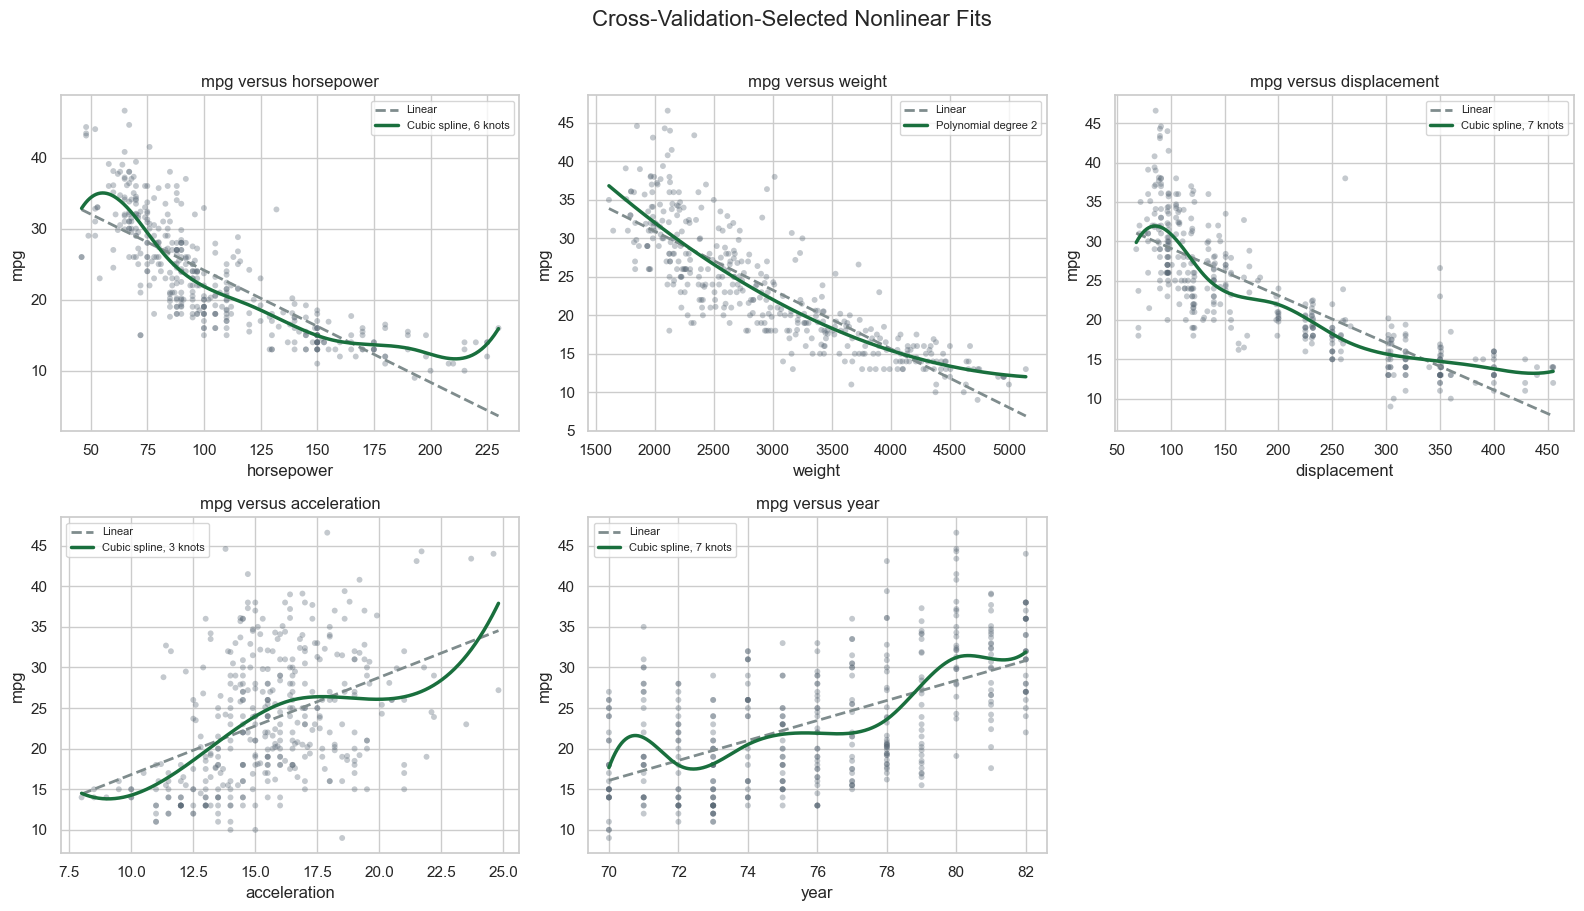

In [4]:
def model_from_name(name):
    if name.startswith('Polynomial'):
        degree = int(name.split()[-1])
        return make_pipeline(
            PolynomialFeatures(degree=degree, include_bias=False),
            LinearRegression()
        )
    knots = int(name.split(', ')[1].split()[0])
    return make_pipeline(
        SplineTransformer(n_knots=knots, degree=3, include_bias=False),
        LinearRegression()
    )

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.ravel()

for ax, feature in zip(axes, continuous):
    X = Auto[[feature]].to_numpy()
    grid = np.linspace(X.min(), X.max(), 400).reshape(-1, 1)

    linear_model = LinearRegression().fit(X, y)
    nonlinear_model = model_from_name(selected_models[feature]).fit(X, y)

    ax.scatter(X[:, 0], y, s=18, alpha=0.35, color='#566573', edgecolor='none')
    ax.plot(grid[:, 0], linear_model.predict(grid), '--', lw=2, color='#7f8c8d', label='Linear')
    ax.plot(grid[:, 0], nonlinear_model.predict(grid), lw=2.5, color='#196f3d', label=selected_models[feature])
    ax.set(title=f'mpg versus {feature}', xlabel=feature, ylabel='mpg')
    ax.legend(fontsize=8)

axes[-1].axis('off')
fig.suptitle('Cross-Validation-Selected Nonlinear Fits', fontsize=16, y=1.01)
plt.tight_layout()
plt.show()


## Multivariable additive-model comparison

The preceding analyses examine one predictor at a time.  The next comparison evaluates whether nonlinear transformations remain useful when the continuous predictors appear together and `cylinders` and `origin` are included as categorical controls.  The additive spline model permits a separate smooth function for every continuous predictor without adding interactions.

In [5]:
X_all = Auto[continuous + categorical].copy()

linear_transformer = ColumnTransformer([
    ('continuous', StandardScaler(), continuous),
    ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical)
])
linear_model = make_pipeline(linear_transformer, LinearRegression())

spline_transformer = ColumnTransformer([
    ('continuous', SplineTransformer(n_knots=4, degree=3, include_bias=False), continuous),
    ('categorical', OneHotEncoder(drop='first', handle_unknown='ignore'), categorical)
])
spline_model = make_pipeline(spline_transformer, LinearRegression())

linear_fold_mse = -cross_val_score(
    linear_model, X_all, y, cv=cv, scoring='neg_mean_squared_error'
)
spline_fold_mse = -cross_val_score(
    spline_model, X_all, y, cv=cv, scoring='neg_mean_squared_error'
)
linear_rmse = np.sqrt(linear_fold_mse.mean())
spline_rmse = np.sqrt(spline_fold_mse.mean())
improvement = 100 * (linear_rmse - spline_rmse) / linear_rmse

comparison = pd.DataFrame({
    'Model': ['Additive linear model', 'Additive spline model'],
    '10-fold CV RMSE (mpg)': [linear_rmse, spline_rmse]
})
display(comparison.style.format({'10-fold CV RMSE (mpg)': '{:.3f}'}))
print(f'Relative RMSE reduction from splines: {improvement:.1f}%')


,Model,10-fold CV RMSE (mpg)
0,Additive linear model,3.184
1,Additive spline model,2.755


Relative RMSE reduction from splines: 13.5%


## Interpretation

The analysis provides convincing evidence that a strictly linear specification is unnecessarily restrictive for the `Auto` data.  The strongest practical evidence of nonlinearity appears for **horsepower**, **weight**, and **displacement**.  Fuel economy declines sharply across portions of these predictors' ranges, but the rate of decline is not constant.  In particular, the horsepower and displacement curves flatten at higher values, while the weight relationship remains decreasing but displays measurable curvature.

The association between **acceleration** and `mpg` is comparatively weak and dispersed.  A formal test may detect curvature, but the reduction in cross-validated error is small; therefore, statistical significance should not be interpreted as strong predictive importance.  **Model year** is positively associated with fuel economy and also departs from a constant linear trend, consistent with more rapid efficiency gains during portions of the late 1970s.

Most importantly, the multivariable additive spline model produces a lower cross-validated RMSE than the additive linear model.  This out-of-sample result shows that the observed curvature is not merely a visual artifact or an in-sample improvement caused by adding parameters.  Allowing flexible functional forms improves the prediction of unseen observations even after the model accounts for multiple vehicle characteristics.

## Conclusion

There is substantial evidence of nonlinear relationships between `mpg` and several predictors in the `Auto` data.  Horsepower, weight, and displacement exhibit the clearest nonlinear patterns; year also contributes a meaningful curved association, whereas acceleration offers weaker practical evidence.  On this basis, an additive spline model is preferable to a strictly linear model when the objective is predictive accuracy.  Nevertheless, the fitted curves near sparsely populated boundaries should be interpreted cautiously, and the associations should not be treated as causal effects because the data are observational.

## Reproducibility note

All model comparisons use shuffled 10-fold cross-validation with `random_state=1`.  Exact numerical results can vary slightly across versions of Python, scikit-learn, and ISLP, but the code records every modeling decision needed to reproduce the analysis.  Run the notebook cells in order from top to bottom to regenerate the tables and figures.